In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
sys.path.append(str(ROOT))

from src.config import FIGURES_DIR, RAW_CHUNKS
from eda.utils import PALETTE, ends_with_punct, has_html, has_wiki_template, load_chunks, save_fig
from eda.utils.plot_utils import FIGSIZE_DEFAULT, FIGSIZE_WIDE
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"ROOT    : {ROOT}")
print(f"Chunks  : {RAW_CHUNKS}")
print(f"Figures : {FIGURES_DIR}")
FIG_DIR = FIGURES_DIR / "01_chunk_pool_eda"
CHUNK_DISTRIBUTION_DIR = FIG_DIR / "chunk_distribution"
TEXT_QUALITY_DIR = FIG_DIR / "text_quality"
SAMPLING_STRATEGY_DIR = FIG_DIR / "sampling_strategy"
for figure_dir in [FIG_DIR, CHUNK_DISTRIBUTION_DIR, TEXT_QUALITY_DIR, SAMPLING_STRATEGY_DIR]:
    figure_dir.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", palette=PALETTE)


ROOT    : D:\wikiqa-data-pipeline
Chunks  : D:\wikiqa-data-pipeline\data\interim\wiki_chunks.jsonl
Figures : D:\wikiqa-data-pipeline\eda\figures


# 01 Chunk Pool EDA

## 1. Chunk Distribution

In [2]:
df = load_chunks(RAW_CHUNKS)
df.head()

Loaded 60,277 chunks from D:\wikiqa-data-pipeline\data\interim\wiki_chunks.jsonl


,chunk_id,pageid,title,section,text,char_count,chunk_index,total_chunks,position_pct,url,domain,scope,context_above,is_intro
0,27580_0000,27580,Âu Lạc,,Âu Lạc (chữ Hán:甌貉/甌駱;) là nhà nước cổ của ngư...,609,0,8,0.0000,https://vi.wikipedia.org/wiki/%C3%82u_L%E1%BA%A1c,history,vn,,True
1,27580_0001,27580,Âu Lạc,Hình thành,Theo hai bộ sử ký Đại Việt sử ký toàn thư (viế...,332,1,8,0.1111,https://vi.wikipedia.org/wiki/%C3%82u_L%E1%BA%A1c,history,vn,Âu Lạc (chữ Hán:甌貉/甌駱;) là nhà nước cổ của ngư...,False
2,27580_0002,27580,Âu Lạc,Hình thành,"""Đất quận Giao Chỉ rất là màu mỡ, ngày xưa có ...",871,2,8,0.2222,https://vi.wikipedia.org/wiki/%C3%82u_L%E1%BA%A1c,history,vn,Theo hai bộ sử ký Đại Việt sử ký toàn thư (viế...,False
3,27580_0003,27580,Âu Lạc,Địa lý,"Sau khi đánh bại vua Hùng thứ 18, Thục Phán sá...",499,3,8,0.3333,https://vi.wikipedia.org/wiki/%C3%82u_L%E1%BA%A1c,history,vn,"""Đất quận Giao Chỉ rất là màu mỡ, ngày xưa có ...",False
4,27580_0005,27580,Âu Lạc,Thành Cổ Loa,Dấu tích của thời Âu Lạc để lại đến ngày nay l...,854,5,8,0.5556,https://vi.wikipedia.org/wiki/%C3%82u_L%E1%BA%A1c,history,vn,"Sau khi đánh bại vua Hùng thứ 18, Thục Phán sá...",False


In [3]:
print(f'Tổng chunks: {len(df):,}')
df.info()
df.describe(include='all').transpose()

Tổng chunks: 60,277
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60277 entries, 0 to 60276
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   chunk_id       60277 non-null  object 
 1   pageid         60277 non-null  int64  
 2   title          60277 non-null  object 
 3   section        60277 non-null  object 
 4   text           60277 non-null  object 
 5   char_count     60277 non-null  int64  
 6   chunk_index    60277 non-null  int64  
 7   total_chunks   60277 non-null  int64  
 8   position_pct   60277 non-null  float64
 9   url            60277 non-null  object 
 10  domain         60277 non-null  object 
 11  scope          60277 non-null  object 
 12  context_above  60277 non-null  object 
 13  is_intro       60277 non-null  bool   
dtypes: bool(1), float64(1), int64(4), object(8)
memory usage: 6.0+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
chunk_id,60277,60277,420248_0020,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pageid,60277.0,NaN,NaN,NaN,5479566.200674,7849056.282521,46.0,57070.0,541159.0,13812638.0,19994276.0
title,60277,5143,Giống vật nuôi Việt Nam,125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
section,60277,16914,,7627,NaN,NaN,NaN,NaN,NaN,NaN,NaN
text,60277,60197,"Theo đó, thành lập đặc khu Phú Quốc thuộc tỉnh...",8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
char_count,60277.0,NaN,NaN,NaN,721.320354,242.514074,200.0,524.0,810.0,926.0,1644.0
chunk_index,60277.0,NaN,NaN,NaN,15.779534,19.564171,0.0,3.0,8.0,21.0,131.0
total_chunks,60277.0,NaN,NaN,NaN,30.896013,28.859131,1.0,9.0,20.0,44.0,125.0
position_pct,60277.0,NaN,NaN,NaN,0.489398,0.31175,0.0,0.2222,0.5,0.75,1.0
url,60277,5143,https://vi.wikipedia.org/wiki/Gi%E1%BB%91ng_v%...,125,NaN,NaN,NaN,NaN,NaN,NaN,NaN


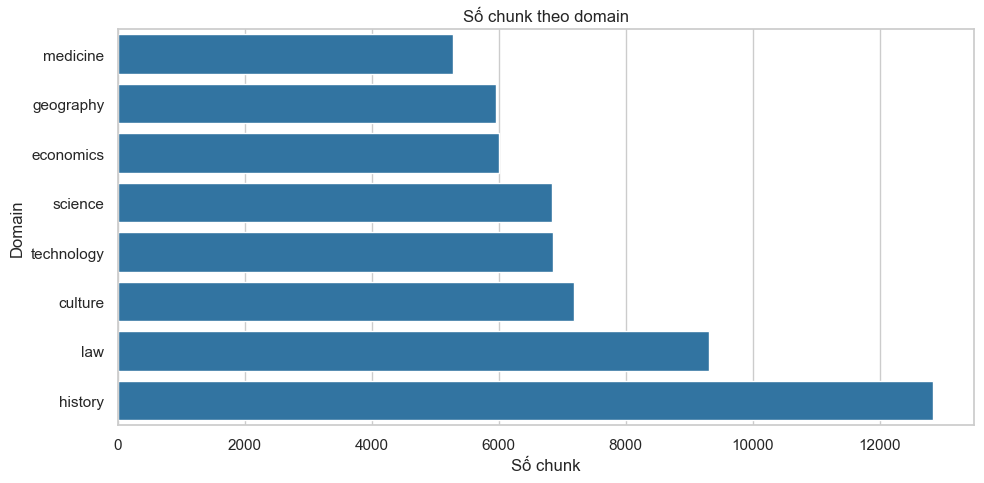

In [4]:
chunk_per_domain = df['domain'].value_counts().sort_values()
fig, ax = plt.subplots(figsize=FIGSIZE_DEFAULT)
sns.barplot(x=chunk_per_domain.values, y=chunk_per_domain.index, ax=ax)
ax.set_title('Số chunk theo domain')
ax.set_xlabel('Số chunk')
ax.set_ylabel('Domain')
save_fig(fig, CHUNK_DISTRIBUTION_DIR, 'bar_chunk_per_domain.png')

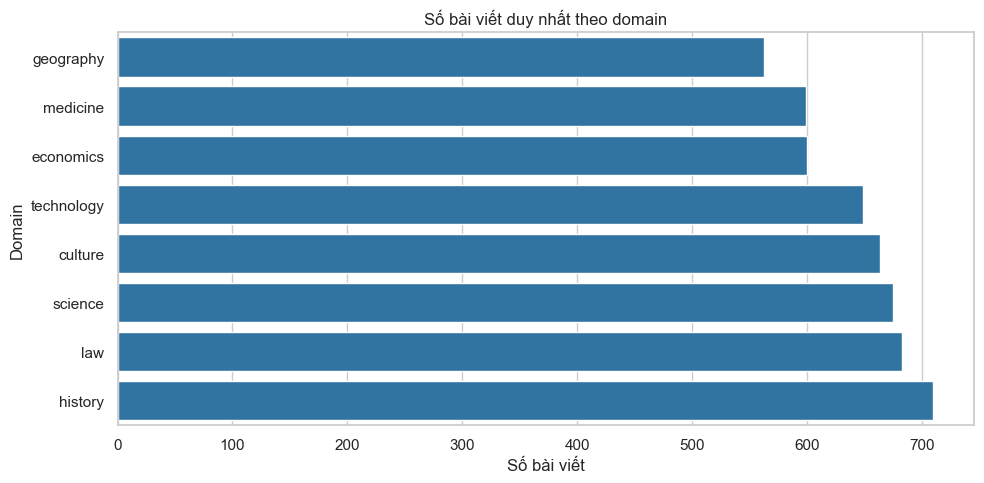

In [5]:
unique_titles = df.groupby('domain')['title'].nunique().sort_values()
fig, ax = plt.subplots(figsize=FIGSIZE_DEFAULT)
sns.barplot(x=unique_titles.values, y=unique_titles.index, ax=ax)
ax.set_title('Số bài viết duy nhất theo domain')
ax.set_xlabel('Số bài viết')
ax.set_ylabel('Domain')
save_fig(fig, CHUNK_DISTRIBUTION_DIR, 'bar_unique_titles_per_domain.png')

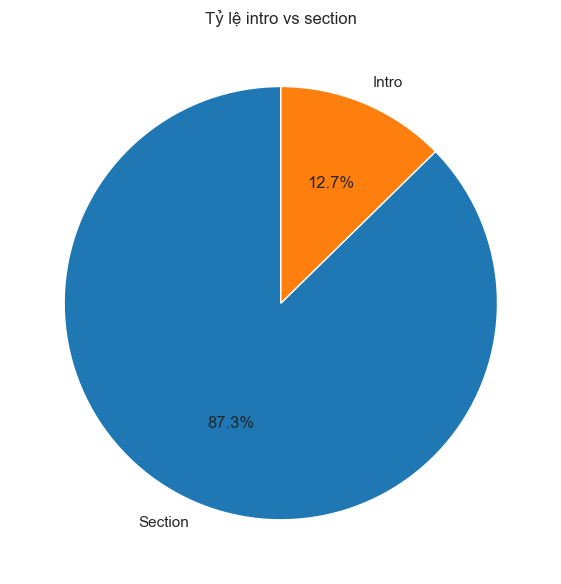

In [6]:
intro_counts = df['section'].fillna('').eq('').value_counts().rename(index={True: 'Intro', False: 'Section'})
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(intro_counts.values, labels=intro_counts.index, autopct='%1.1f%%', startangle=90)
ax.set_title('Tỷ lệ intro vs section')
save_fig(fig, CHUNK_DISTRIBUTION_DIR, 'pie_intro_vs_section.png')

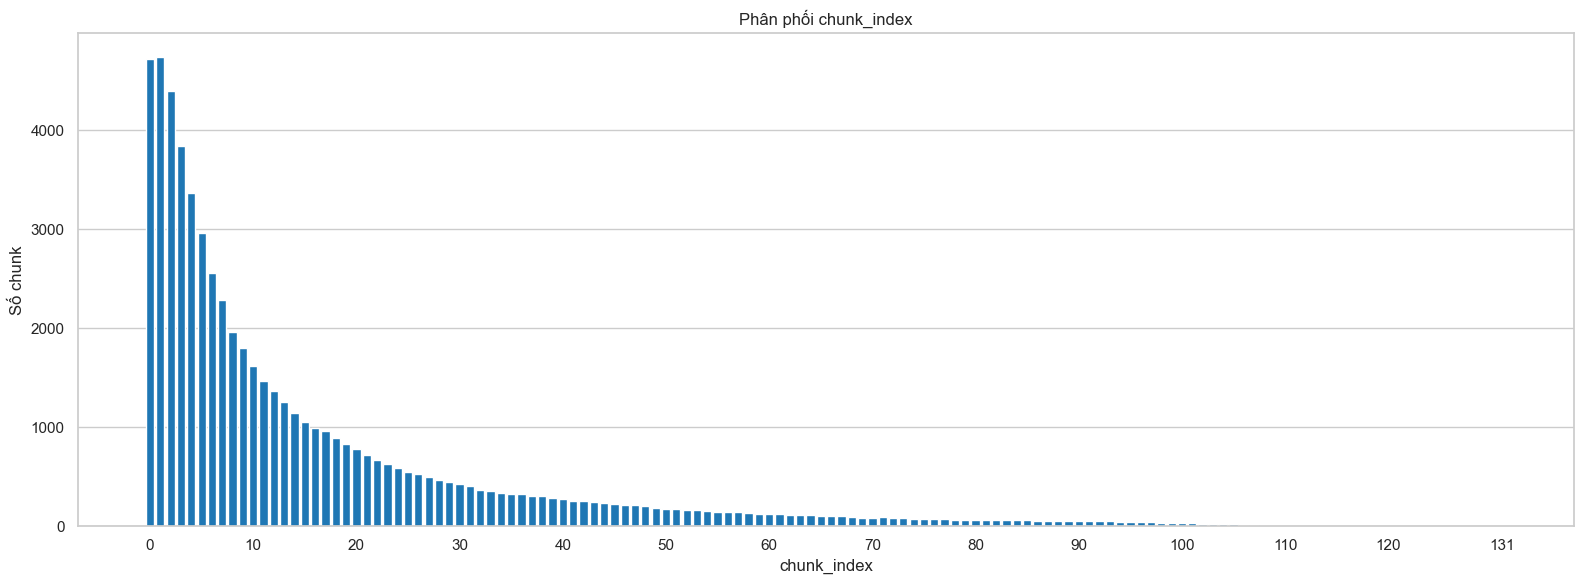

In [7]:
chunk_index_dist = df['chunk_index'].value_counts().sort_index()
tick_step = max(1, len(chunk_index_dist) // 12)
tick_positions = list(range(0, len(chunk_index_dist), tick_step))
if tick_positions[-1] != len(chunk_index_dist) - 1:
    tick_positions.append(len(chunk_index_dist) - 1)
fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(chunk_index_dist.index, chunk_index_dist.values, color=sns.color_palette(PALETTE)[0], width=0.8)
ax.set_title('Phân phối chunk_index')
ax.set_xlabel('chunk_index')
ax.set_ylabel('Số chunk')
ax.set_xticks(chunk_index_dist.index[tick_positions])
ax.set_xticklabels(chunk_index_dist.index[tick_positions], rotation=0)
ax.grid(axis='x', visible=False)
save_fig(fig, CHUNK_DISTRIBUTION_DIR, 'bar_chunk_index_distribution.png')

## 2. Text Quality

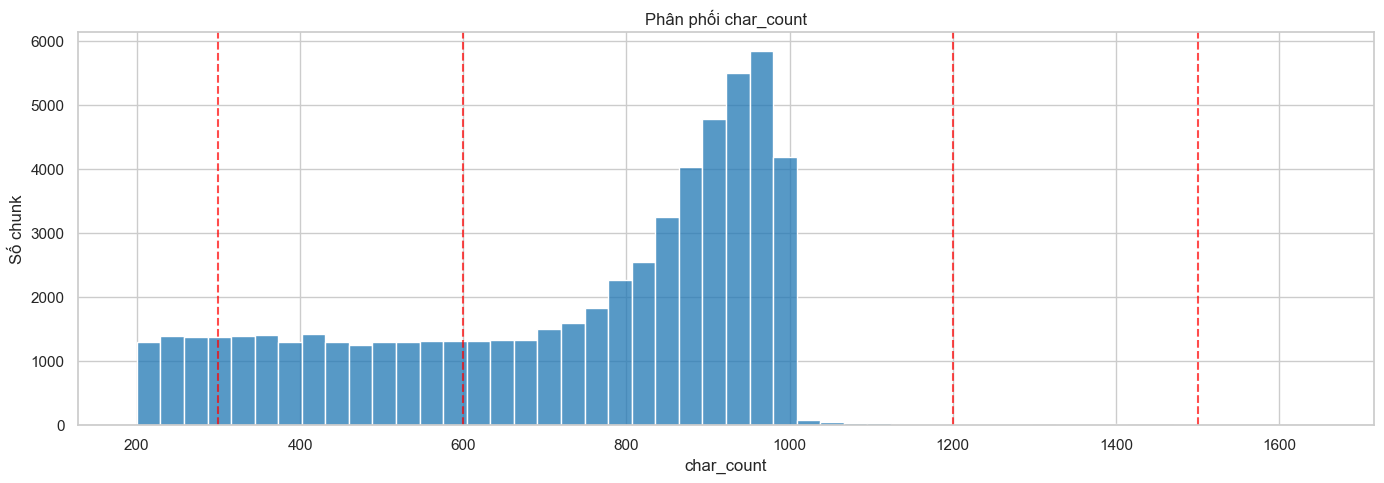

In [8]:
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
sns.histplot(df['char_count'], bins=50, ax=ax)
for threshold in [300, 600, 1200, 1500]:
    ax.axvline(threshold, color='red', linestyle='--', alpha=0.7)
ax.set_title('Phân phối char_count')
ax.set_xlabel('char_count')
ax.set_ylabel('Số chunk')
save_fig(fig, TEXT_QUALITY_DIR, 'hist_char_count.png')

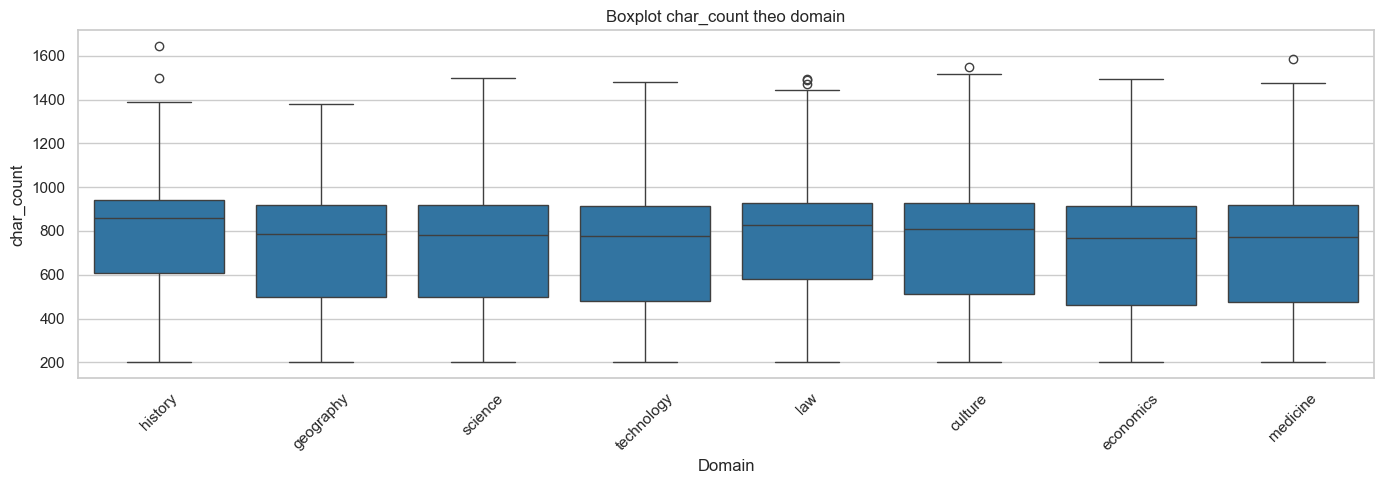

In [9]:
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
sns.boxplot(data=df, x='domain', y='char_count', ax=ax)
ax.set_title('Boxplot char_count theo domain')
ax.set_xlabel('Domain')
ax.set_ylabel('char_count')
ax.tick_params(axis='x', rotation=45)
save_fig(fig, TEXT_QUALITY_DIR, 'boxplot_char_count_per_domain.png')

In [10]:
df['ends_with_punct'] = df['text'].apply(ends_with_punct)
df['has_html'] = df['text'].apply(has_html)
df['has_wiki_tmpl'] = df['text'].apply(has_wiki_template)
print(f"Tỷ lệ chunk kết thúc bằng dấu câu: {df['ends_with_punct'].mean() * 100:.2f}%")
print(f"Số chunk còn HTML: {int(df['has_html'].sum())}")
print(f"Số chunk còn wiki template/markup: {int(df['has_wiki_tmpl'].sum())}")

Tỷ lệ chunk kết thúc bằng dấu câu: 98.25%
Số chunk còn HTML: 0
Số chunk còn wiki template/markup: 29


In [11]:
df.nsmallest(20, 'char_count')[['chunk_id', 'domain', 'char_count', 'text']]

,chunk_id,domain,char_count,text
395,13712477_0030,history,200,"Viện Sử học (1981). ""Nghiên cứu lịch sử, Số ph..."
1963,41852_0015,history,200,Thực ra nhà Hậu Trần là một cuộc khởi nghĩa th...
2472,343848_0000,history,200,"Diệp Văn Cương (葉文疆, 1862- 1929), tự Thọ Sơn, ..."
4021,376865_0000,history,200,Thủ công nghiệp Đại Việt thời Lê Sơ chiếm vị t...
5766,1646233_0000,history,200,Mặt trận Quốc dân Đảng (hay Mặt trận Quốc dân ...
6621,4314_0042,history,200,ISBN 978-1-60741-826-9. Bản gốc lưu trữ ngày 1...
7314,334874_0002,history,200,East African Community in Europe Lưu trữ ngày ...
9103,13824_0050,history,200,"Thế kỷ XVI và thế kỷ XVII, sự nở rộ văn hóa ở ..."
13641,1548771_0003,geography,200,"Hòn Bà nằm trên một vị trí khá cao, hơn 1.500 ..."
14008,312747_0009,geography,200,Ban quản lý vườn cũng có kế hoạch hỗ trợ rút n...


In [12]:
df.nlargest(20, 'char_count')[['chunk_id', 'domain', 'char_count', 'text']]

,chunk_id,domain,char_count,text
11193,19744865_0004,history,1644,1348 TCN —Pharaoh Amenhotep IV đổi tên thành A...
57829,15443813_0003,medicine,1586,Một số nguyên nhân gây giảm trương lực:\nBất t...
43515,3156057_0003,culture,1551,Nhìn lại tân nhạc Việt Nam thì thi sĩ Du Tử Lê...
42676,149090_0006,culture,1519,Các lễ hội là di sản văn hóa quốc gia\nTính đế...
12210,562850_0002,history,1498,"Phụ nữ có các vai trò là người yêu, người vợ, ..."
25398,3116369_0037,science,1498,Mọi trạng thái lượng tử của trường có thể thu ...
34858,577900_0003,law,1496,Dưới đây là những Hiệp định cơ bản được liệt k...
50552,17470971_0008,economics,1493,Hệ thống UniPass (bao gồm thẻ NFC và mã QR) hi...
39518,33622_0001,law,1490,- Nhận quyết định đưa vụ án ra xét xử; quyết đ...
51636,85085_0032,economics,1480,Cho luôn phần chưa lấy: bằng cách Cấp giấy chứ...


In [13]:
df.groupby('domain', group_keys=False).sample(3, random_state=42)[['chunk_id', 'domain', 'char_count', 'text']]

,chunk_id,domain,char_count,text
43364,58922_0002,culture,836,Múa rối nước ra đời cùng nền văn minh lúa nước...
44686,19425906_0014,culture,844,Cả lũ triều thần trong Phạm Tải – Ngọc Hoa khô...
43565,19796882_0041,culture,531,Kể từ ngày thành lập Dàn nhạc Giao hưởng quốc ...
52323,289160_0000,economics,768,‘’’ Định giá dựa vào cạnh tranh’’’ là một tron...
51938,1675_0007,economics,252,Ngành kế toán này cũng được nghiên cứu như một...
52784,2261020_0005,economics,212,Trong khi Hình 5 cho thấy một câu chuyện tương...
16465,12458_0081,geography,999,Vị trí cầu nối và nguồn tài nguyên giàu có của...
17836,19797459_0003,geography,934,"Tuy nhiên căn cứ vào tổng kết của các học giả,..."
13184,19497024_0002,geography,954,"Trong lịch sử, dãy Trường Sơn là ranh giới tự ..."
1240,4169_0005,history,935,"Sử ký do Tư Mã Trinh thời Đường biên tập, dẫn ..."


## 3. Sampling Strategy

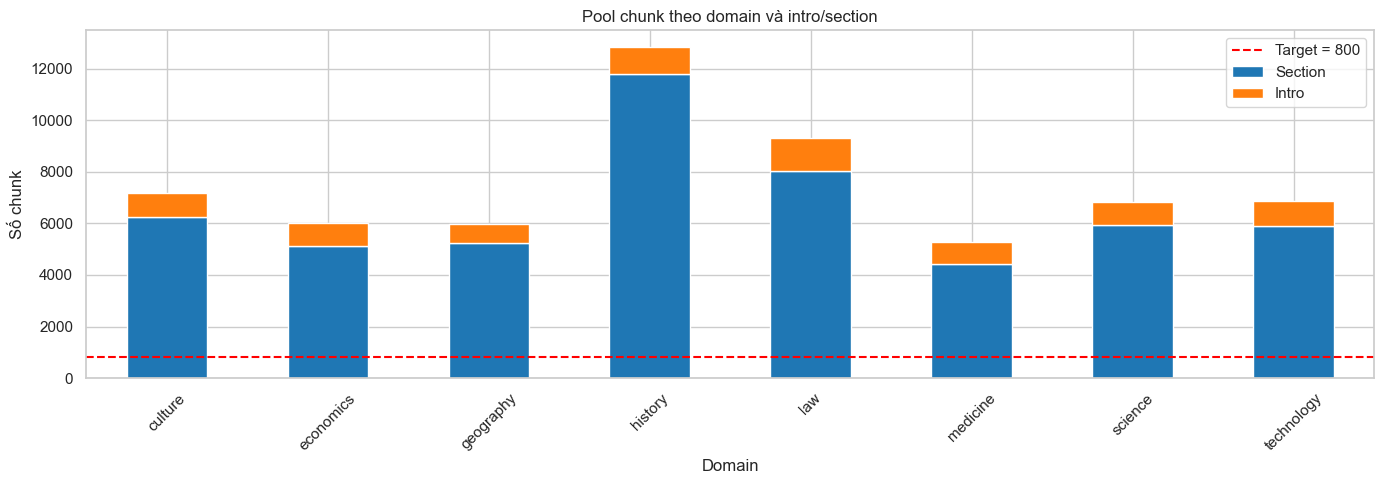

is_intro,Section,Intro
domain,,
culture,6237,942
economics,5113,892
geography,5252,712
history,11794,1046
law,8036,1268
medicine,4408,875
science,5924,919
technology,5886,973


In [14]:
pivot = df.assign(is_intro=df['section'].fillna('').eq('')).groupby(['domain', 'is_intro']).size().unstack(fill_value=0).rename(columns={True: 'Intro', False: 'Section'})
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
pivot.plot(kind='bar', stacked=True, ax=ax)
ax.axhline(800, color='red', linestyle='--', label='Target = 800')
ax.set_title('Pool chunk theo domain và intro/section')
ax.set_xlabel('Domain')
ax.set_ylabel('Số chunk')
ax.tick_params(axis='x', rotation=45)
ax.legend()
save_fig(fig, SAMPLING_STRATEGY_DIR, 'stacked_bar_intro_per_domain.png')
pivot

In [15]:
domain_pool = df.groupby('domain').size().rename('chunk_count')
domain_pool[domain_pool < 800].sort_values()

Series([], Name: chunk_count, dtype: int64)

In [16]:
short_chunk_ratio = df['char_count'].lt(300).groupby(df['domain']).mean().mul(100).sort_values(ascending=False)
short_chunk_ratio.to_frame(name='short_chunk_ratio_pct')

,short_chunk_ratio_pct
domain,
economics,9.691923
medicine,9.672535
technology,9.185012
geography,8.534541
science,8.373520
culture,8.106979
history,6.020249
law,5.986672


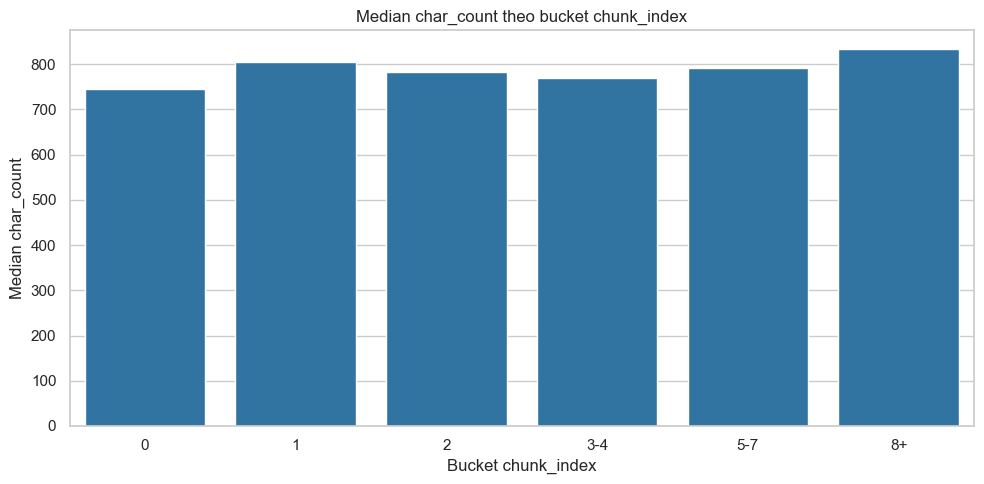

chunk_index_bucket
0      745.5
1      804.0
2      783.0
3-4    769.0
5-7    791.0
8+     833.0
Name: char_count, dtype: float64

In [17]:
bucket = pd.cut(df['chunk_index'], bins=[-1, 0, 1, 2, 4, 7, float('inf')], labels=['0', '1', '2', '3-4', '5-7', '8+'])
median_charcount_by_bucket = df.assign(chunk_index_bucket=bucket).groupby('chunk_index_bucket', observed=False)['char_count'].median()
fig, ax = plt.subplots(figsize=FIGSIZE_DEFAULT)
sns.barplot(x=median_charcount_by_bucket.index.astype(str), y=median_charcount_by_bucket.values, ax=ax, color=sns.color_palette(PALETTE)[0])
ax.set_title('Median char_count theo bucket chunk_index')
ax.set_xlabel('Bucket chunk_index')
ax.set_ylabel('Median char_count')
save_fig(fig, SAMPLING_STRATEGY_DIR, 'bar_median_charcount_per_chunk_index_bucket.png')
median_charcount_by_bucket